# 4장 실습 ① — 정규화를 안 하면 무슨 일이 생기는가

**Keras 3 판**

§4.3 ④는 나이(0~100)와 소득(0~1억)을 한 모델에 넣는 이야기였습니다.
그 상황을 사과 데이터로 만들어 놓고 **직접 무너뜨려 봅니다.**

> **"정규화 안 하면 학습이 잘 안 됩니다"** 는 말은 너무 자주 들어서
> 아무 느낌이 없습니다. 얼마나 안 되는지 숫자로 보십시오.

## 4.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 4.1 크기가 1만 배 다른 두 축

In [3]:
# 사과는 [크기, 색깔] 둘 다 0~4 입니다. 스케일이 같아서 문제가 안 생깁니다.
# 그래서 **색깔 축만 10,000배** 키웁니다. §4.3 ④의 "소득" 자리입니다.
x, y = data.apples(2000, seed=42)
x = x.copy()
x[:, 1] = x[:, 1] * 10000.0

s0 = data.split(x, y, seed=42)
print(s0.summary())
print()
print(f"크기 축   {s0.x_train[:, 0].min():10.2f} ~ {s0.x_train[:, 0].max():10.2f}")
print(f"색깔 축   {s0.x_train[:, 1].min():10.2f} ~ {s0.x_train[:, 1].max():10.2f}")
print()
print("★ 2장 §2.5의 조정 값 = 오차 × **입력값** × 학습률")
print("  입력값이 곱해집니다. 두 축의 조정 폭이 1만 배 차이 납니다.")

구분            개수  입력 shape
train       1200  (2,)
val          400  (2,)
test         400  (2,)

크기 축         0.20 ~       4.00
색깔 축      2046.86 ~   39977.54

★ 2장 §2.5의 조정 값 = 오차 × **입력값** × 학습률
  입력값이 곱해집니다. 두 축의 조정 폭이 1만 배 차이 납니다.


## 4.2 정규화 세 가지

In [4]:
def prepare(s, how):
    """정규화 세 가지. **반드시 학습 데이터의 통계로만 합니다.**

    왜 학습 데이터의 통계로만 하는지는 다음 실습(ch04_leakage)에서 봅니다.
    """
    if how == "none":
        return s
    if how == "minmax":                       # (x - min) / (max - min)
        lo, hi = s.x_train.min(0), s.x_train.max(0)
        f = lambda a: (a - lo) / (hi - lo)
    else:                                     # (x - 평균) / 표준편차
        mu, sd = s.x_train.mean(0), s.x_train.std(0)
        f = lambda a: (a - mu) / sd
    return data.Split(f(s.x_train), s.y_train,
                      f(s.x_val), s.y_val,
                      f(s.x_test), s.y_test)


for how in ("none", "minmax", "standard"):
    t = prepare(s0, how).x_train
    print(f"{how:<10} 크기 {t[:, 0].min():9.2f}~{t[:, 0].max():<9.2f} "
          f"색깔 {t[:, 1].min():9.2f}~{t[:, 1].max():<9.2f}")

none       크기      0.20~4.00      색깔   2046.86~39977.54 
minmax     크기      0.00~1.00      색깔      0.00~1.00     
standard   크기     -1.69~1.70      색깔     -1.72~1.75     


## 4.3 학습 함수 — 여기만 판마다 다릅니다

In [5]:
import keras
from keras import layers

def train(s, lr, epochs=30):
    """같은 모델, 같은 조건. **이 함수만 판마다 다릅니다.**"""
    dlbook.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
    h = m.fit(s.x_train, s.y_train, epochs=dlbook.smoke.epochs(epochs),
              batch_size=32, verbose=0)
    pred = (m.predict(s.x_test, verbose=0).ravel() > 0.5).astype(int)
    return metrics.accuracy(s.y_test, pred), h.history

## 4.4 정규화 × 학습률 열두 판

In [6]:
LRS = [0.001, 0.01, 0.1, 1.0]
HOWS = ["none", "minmax", "standard"]
NAME = {"none": "정규화 안 함", "minmax": "최소-최대", "standard": "표준화"}

acc = {}
hist = {}
print(f"{'':<14}" + "".join(f"{f'lr={l}':>12}" for l in LRS))
print("-" * (14 + 12 * len(LRS)))
for how in HOWS:
    s = prepare(s0, how)
    row = f"{NAME[how]:<14}"
    for lr in LRS:
        a, h = train(s, lr)
        acc[(how, lr)] = a
        hist[(how, lr)] = h
        row += f"{a:>12.3f}"
    print(row, flush=True)
    dlbook.record(f"ch04_norm_{how}_best", max(acc[(how, l)] for l in LRS))

base = max(np.mean(s0.y_test), 1 - np.mean(s0.y_test))   # 그냥 많은 쪽을 찍은 값
def n_good(how): return sum(acc[(how, l)] >= 0.90 for l in LRS)

print()
print(f"★ **정규화를 안 하면 네 학습률 어디에서도 못 배웁니다.** "
      f"(0.90 넘김 {n_good('none')}/{len(LRS)})")
print(f"  {base:.3f} 는 그냥 많은 쪽을 찍으면 나오는 값입니다. "
      f"가장 나쁜 것은 {min(acc[('none', l)] for l in LRS):.3f} 로, 찍는 것보다도 못합니다.")
print(f"★ 정규화를 하면 **적어도 세 곳에서** 0.90을 넘습니다. "
      f"(최소-최대 {n_good('minmax')}/{len(LRS)}, 표준화 {n_good('standard')}/{len(LRS)})")
print("  → 연습문제 7의 답입니다. **학습률로는 회복되지 않습니다.**")

                  lr=0.001     lr=0.01      lr=0.1      lr=1.0
--------------------------------------------------------------


정규화 안 함              0.665       0.335       0.665       0.665


ch04_norm_none_best = 0.6650


최소-최대                0.943       0.945       0.950       0.940


ch04_norm_minmax_best = 0.9500


표준화                  0.948       0.943       0.945       0.665


ch04_norm_standard_best = 0.9475

★ **정규화를 안 하면 네 학습률 어디에서도 못 배웁니다.** (0.90 넘김 0/4)
  0.665 는 그냥 많은 쪽을 찍으면 나오는 값입니다. 가장 나쁜 것은 0.335 로, 찍는 것보다도 못합니다.
★ 정규화를 하면 **적어도 세 곳에서** 0.90을 넘습니다. (최소-최대 4/4, 표준화 3/4)
  → 연습문제 7의 답입니다. **학습률로는 회복되지 않습니다.**


## 4.5 손실 곡선

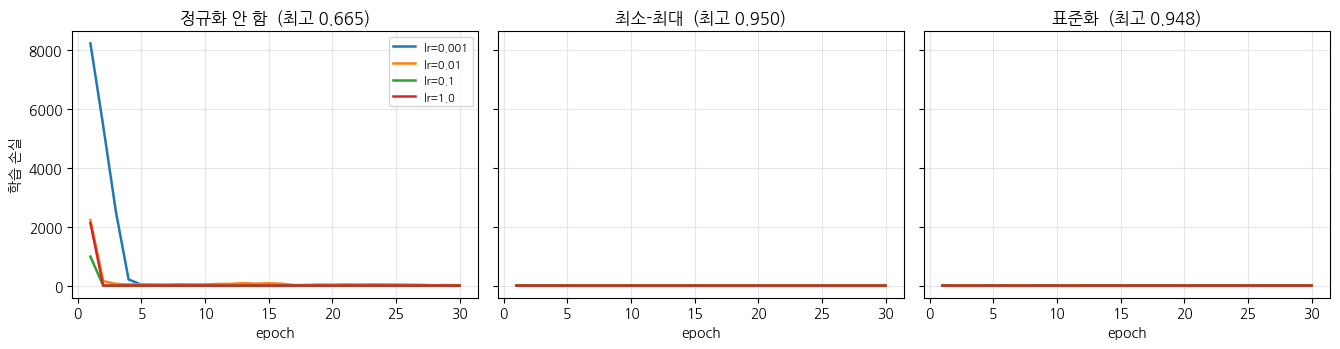

★ 왼쪽 그림의 손실은 **내려가다 마는 것이 아니라 아예 안 내려갑니다.**
  색깔 축의 가중치는 한 걸음에 너무 크게 튀고,
  크기 축의 가중치는 거의 안 움직입니다. 같은 학습률로는 둘 다 못 맞춥니다.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True)
for ax, how in zip(axes, HOWS):
    for lr in LRS:
        h = hist[(how, lr)]
        ax.plot(range(1, len(h["loss"]) + 1), h["loss"], marker="", lw=1.8,
                label=f"lr={lr}")
    ax.set_title(f"{NAME[how]}  (최고 {max(acc[(how, l)] for l in LRS):.3f})")
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0].set_ylabel("학습 손실"); axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

print("★ 왼쪽 그림의 손실은 **내려가다 마는 것이 아니라 아예 안 내려갑니다.**")
print("  색깔 축의 가중치는 한 걸음에 너무 크게 튀고,")
print("  크기 축의 가중치는 거의 안 움직입니다. 같은 학습률로는 둘 다 못 맞춥니다.")

## 정리

| 정규화 | lr=0.001 | lr=0.01 | lr=0.1 | lr=1.0 |
|---|:--:|:--:|:--:|:--:|
| **안 함** | **0.665** | **0.335** | **0.665** | **0.665** |
| 최소-최대 | 0.943 | 0.945 | 0.950 | 0.940 |
| 표준화 | 0.948 | 0.943 | 0.945 | 0.665 |

- **정규화를 안 하면 학습률로 못 살립니다.** 네 개를 훑어도 전부 실패합니다.
  0.665는 많은 쪽을 그냥 찍은 값입니다. lr=0.01의 0.335는 **찍는 것보다도 못합니다** — 발산한 것입니다.
- **최소-최대는 학습률에 관대합니다.** 값이 0~1로 갇히기 때문입니다.
- **큰 학습률에서는 정규화를 해도 무너집니다.** §4.3의 표대로
  "대체로 표준화"가 맞지만, **정규화와 학습률은 짝으로 봐야 합니다.**
  (5장에서 학습률만 따로 다룹니다)

> 세 판의 숫자가 조금씩 다릅니다. 초기값을 뽑는 방식이 프레임워크마다
> 달라서입니다. **결론은 셋 다 같습니다.**

### 연습

1. 색깔 축을 10,000배가 아니라 **10배**만 키우면 어떻게 됩니까.
   몇 배부터 학습이 무너지기 시작합니까.
2. 정규화를 **한 축에만** 걸어 보십시오. 그것으로 충분합니까.
3. lr=1.0에서 무너진 것은 epoch을 늘리면 회복됩니까.
4. 5장에서 배울 것을 미리 써 보십시오 — 옵티마이저를 `Adam` 대신
   `SGD` 로 바꾸면 정규화의 중요도가 커집니까 작아집니까.